In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.special import factorial
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import math
from IPython.display import Latex
from scipy.integrate import nquad

import matplotlib
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import time

In [2]:
c=2.998*10**8 #in m/s

#in natural units:
v0 = 220*1000/c
v_esc = 500*1000/c 
v_E = 240*1000/c 
f=28 #coupling strength

#in eV
w_minus = 60*10**-3
w_plus = 20*10**-3
m_Si_nucleus = 2.616e10
proton_mass= 938.272e6

dm_density = 0.3e9 #eV/cm^3, plus minus 0.1
target_density = 1.307e33 #eV/cm^3 from silicon density of 2329.6 kg/m3

#in 1/eV
a_Si = 2*np.pi/(2.28*1000) #Silicon lattice constant
a0 = 2.68e-4 #Bohr radius

# Structure Factor

The equation for the Structure Factor is as follows:
\begin{aligned}
    S(q,\omega) &= \sum_{\ell,\ell'} |f|^2 C_{\ell, \ell'} \\
    &= 2|f|^2 (C_{\ell=\ell'}+C_{\ell \neq \ell'})
\end{aligned}
The diagonal term is $$ C_{\boldsymbol{\ell}d} = \frac{1}{V} e^{-2W_d(\boldsymbol{q})} \sum_{n=0} (\frac{q^2}{4m_d})^n \sum_{j=0}^n \frac{2\pi}{j!(n-j)!\omega_+^j \omega_-^{n-j}} \delta(j\omega_++(n-j)\omega_--\omega)$$ and the off-diagonal is $$C_{\boldsymbol{\ell '}\boldsymbol{\ell} d}=\frac{1}{V}e^{i\boldsymbol{q}\cdot(\boldsymbol{l}-\boldsymbol{\ell'})} e^{-2W_d(\boldsymbol{q})} \sum_{n=0}^{\omega/\omega_+} (\frac{q^2}{4m_d})^n \sum_{j=0}^n \frac{2\pi(-1)^{n-j}}{j!(n-j)!\omega_+^j \omega_-^{n-j}} \delta(j\omega_++(n-j)\omega_--\omega)$$

The function $W_d(q)$ is the Debye-Waller factor: $W_d(q)=\frac{q^2}{8m_d}(\frac{1}{\omega_1}+\frac{1}{\omega_2})$. When you integrate with $\omega$, the delta function gets removed, leaving a sum based on n and j for set values of $\omega_{n,j}$



In [3]:
"""
The Debye-Waller function for a two-site lattice
@params 
    q: the momentum transfer from dark matter to the crystal
    m: mass of nucleus in the crystal
    w1, w2: energy levels of the element
"""
def debye_waller(q, m, w1,w2):
    return q**2/(8*m)*(1/w1+1/w2)

In [4]:
"""
The diagonal terms (without the delta function) for one n,j combination
@params
    q: the momentum transfer from dark matter to the crystal
    m: mass of nucleus in the crystal
    w1, w2: energy levels of the element
    n: principle phonon number
    j: phonon mode number
    V: 1D volume (ie length) of target crystal
"""
def diagonal_C_true(q, m, w1,w2, n, j, V=a_Si):
    expDebyeWaller = np.exp(-2*debye_waller(q, m, w1,w2))
    c=expDebyeWaller/V * (q**2/(4*m))**n * 2*np.pi/(factorial(j)*factorial(n-j)*w1**j*w2**(n-j))
    return c

In [5]:
"""
The off-diagonal terms (without the delta function) for one n,j combination
@params
    q: the momentum transfer from dark matter to the crystal
    m: mass of nucleus in the crystal
    w1, w2: energy levels of the element
    n: principle phonon number
    j: phonon mode number
    V: 1D volume (ie length) of target crystal
    a: the lattice constant of the crystal
"""
def offDiagonal_C_true(q, m, w1,w2, n, j, V=a_Si, a=a_Si):
    expDebyeWaller = np.exp(-2*debye_waller(q, m, w1,w2))
    c=expDebyeWaller/V * (q**2/(4*m))**n * 2*np.pi/(factorial(j)*factorial(n-j)* w1**j * w2**(n-j))
    if (n-j)%2==1:
        c = -c
    c = c*np.cos(q*a)
    return c

In [6]:
"""
Structure Factor for one n and j pair, integrated with omega to remove the delta function
@params
    q: the momentum transfer from dark matter to the crystal
    m: mass of nucleus in the crystal
    w1, w2: energy levels of the element
    n: principle phonon number
    j: phonon mode number
    V: 1D volume (ie length) of target crystal
    a: the lattice constant of the crystal
    A: coupling strength
"""
def StructureFactor_n_j(q,m, w1, w2, n, j, V, a, A=f):
    return 2*A**2*(diagonal_C_true(q, m, w1, w2, n, j, V)
                      +offDiagonal_C_true(q, m, w1, w2, n, j, V, a))

In [7]:
"""
Structure Factor for one n, integrated with omega to remove the delta function
@params
    q: the momentum transfer from dark matter to the crystal
    m: mass of nucleus in the crystal
    w1, w2: energy levels of the element
    n: principle phonon number
    V: 1D volume (ie length) of target crystal
    a: the lattice constant of the crystal
    A: coupling strength
"""
def StructureFactor_n(q, m, w1,w2, n, V, a, A=f):
    return sum([2*A**2*(diagonal_C_true(q, m, w1,w2, n, j, V)
                        +offDiagonal_C_true(q, m, w1,w2, n, j, V, a)) for j in range(n+1)] )

In [8]:
"""
Diagonal Structure Factor for one n, integrated with omega to remove the delta function
@params
    q: the momentum transfer from dark matter to the crystal
    m: mass of nucleus in the crystal
    w1, w2: energy levels of the element
    n: principle phonon number
    V: 1D volume (ie length) of target crystal
    A: coupling strength
"""
def StructureFactor_diag(q, m, w1,w2, n, V, A):
    return sum([2*A**2* diagonal_C_true(q, m, w1,w2, n, j, V) for j in range(n+1)] )

In [9]:
#Calculate the structure factor integrated wrt omega for first 4 phonon numbers
q_range = 10**np.linspace(-1, np.log10(300), 3000) #keV
S_int_w = [[StructureFactor_n(q*1000, m_Si_nucleus, w_plus, w_minus, n, 1, a_Si, 1) for q in q_range] 
           for n in range(1,5)] #structure factor
S_int_diag= [[StructureFactor_diag(q*1000, m_Si_nucleus, w_plus, w_minus, n, 1, 1) for q in q_range] 
            for n in range(1,5)] #diagonal portion for reference

In [10]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix', 
    'font.size': 17,
    'figure.dpi':200           
})

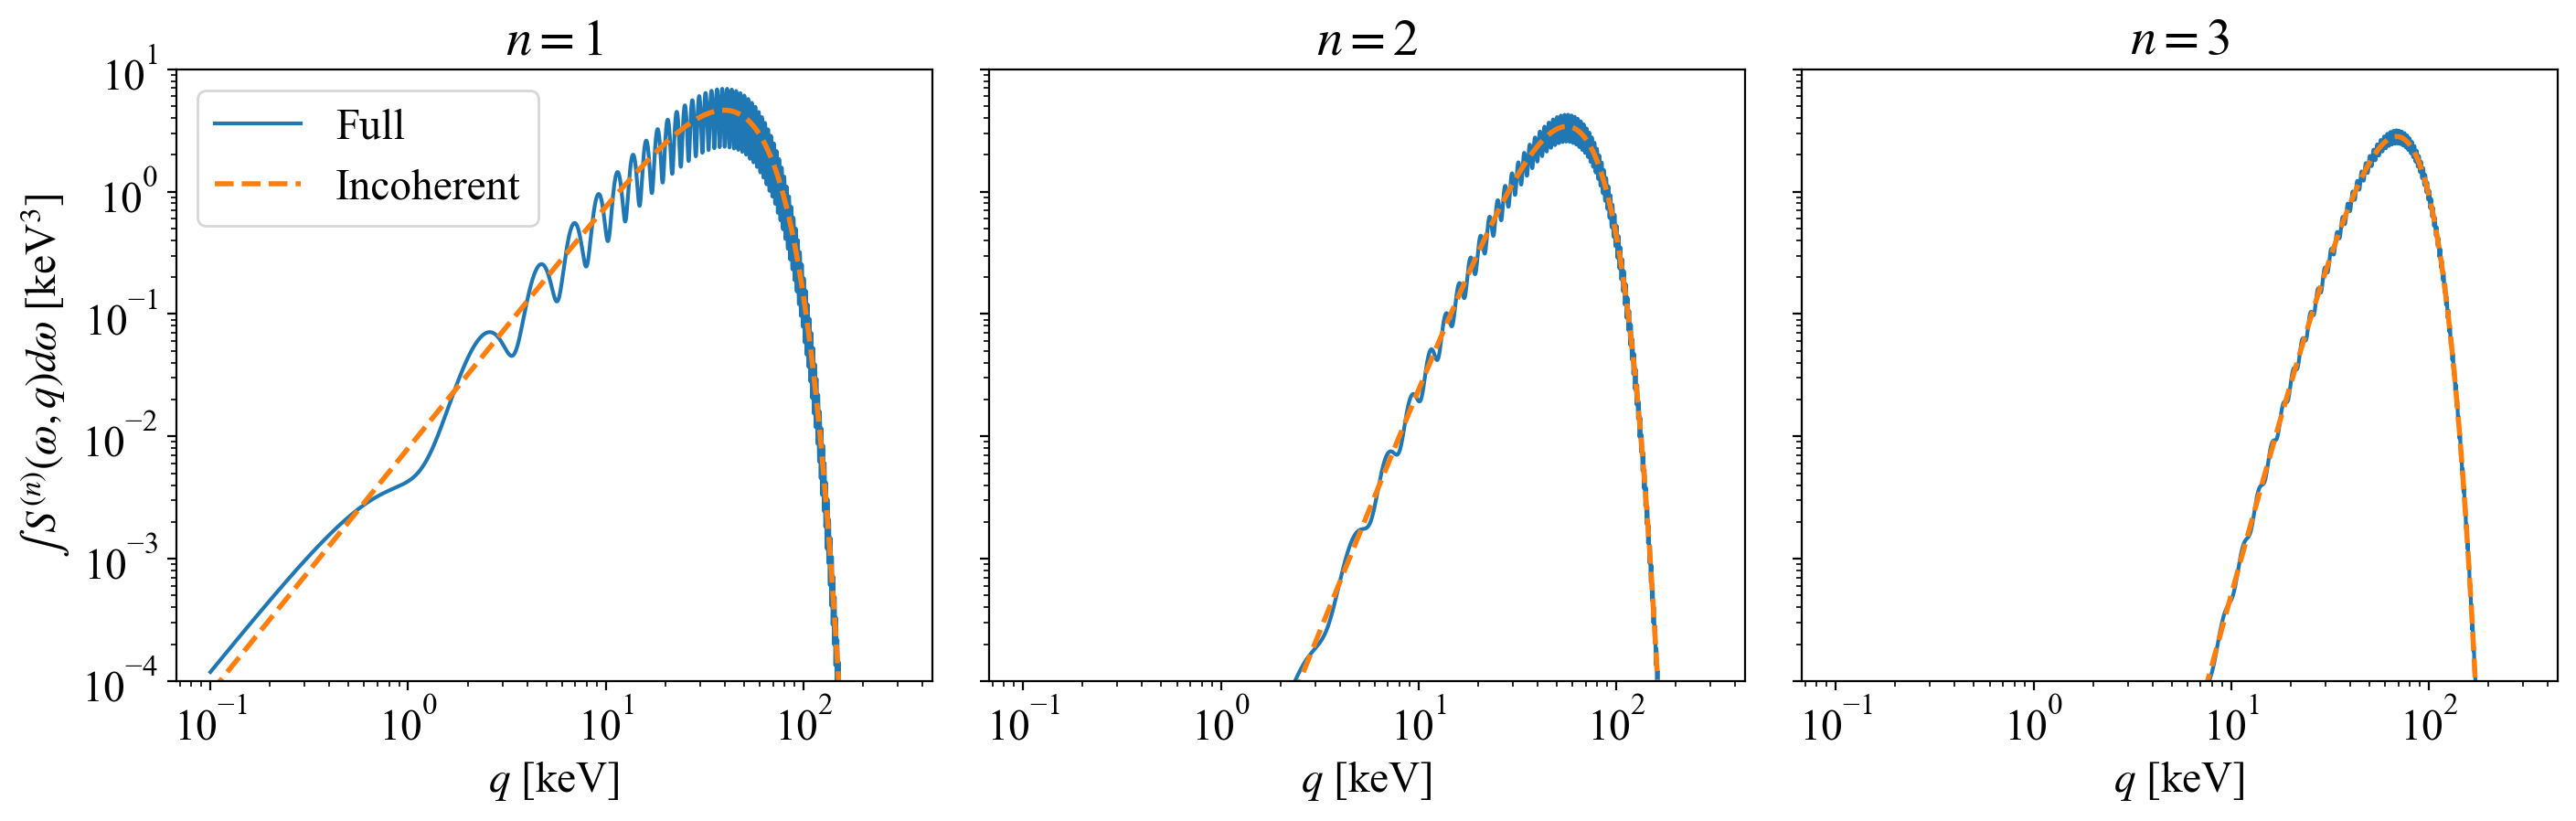

In [11]:
fig, axs = plt.subplots(1, 3, sharey=True, figsize=(14.4, 4.8)) 

for n in range(3):
    axs[n].plot(q_range, S_int_w[n], linewidth=1.5, label="Full")
    axs[n].plot(q_range, S_int_diag[n], linewidth=2, linestyle="--", label="Incoherent")
    axs[n].set_xscale('log')
    axs[n].set_title("$n=$" + str(n+1))
    # axs[n].axvline(2.28/2, color="gray", linestyle=":", label=r"$q_{BZ}$")

axs[0].legend()

plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-4,10)
for ax in axs.flat:
    ax.set(xlabel='$q$ [keV]', ylabel=r'$\int \,S^{(n)}(\omega,q)d\omega$ [keV$^3$]')

for ax in axs.flat:
    ax.label_outer()

plt.tight_layout()
plt.show()